<a href="https://colab.research.google.com/github/tomikakenzhetaeva23-star/student-perfomance-patterns/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Analysis: Unsupervised Clustering vs. Supervised Neural Network

**Автор:** Томирис  
**Цель исследования:** Изучить, образуют ли привычки студентов естественные кластеры (K-Means), и обучить полносвязную нейросеть (PyTorch) для предсказания сбалансированных групп успеваемости без утечки данных.

In [1]:
import zipfile
import pandas as pd
import numpy as np
import torch

# 1. Распаковка архива
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Загружаем датасет (в архиве Kaggle файл обычно называется StudentPerformanceFactors.csv)
df = pd.read_csv('StudentPerformanceFactors.csv')

# 2. Фиксация размера ДО и ПОСЛЕ очистки от пропусков
shape_before = df.shape
df = df.dropna()
shape_after = df.shape

print(f"Размер датасета до очистки: {shape_before}")
print(f"Размер датасета после dropna(): {shape_after}")
print(f"Удалено строк с пропусками: {shape_before[0] - shape_after[0]}")

Размер датасета до очистки: (6607, 20)
Размер датасета после dropna(): (6378, 20)
Удалено строк с пропусками: 229


Здесь мы очищаем Data set от пропущенных значений. Это нужно для того, чтобы предотвратить ошибки при умножении матриц.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'Hours_Studied', 'Attendance', 'Sleep_Hours',
    'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity'
]

# Create Performance_Group from Exam_Score by quantiles (e.g., 3 groups: Low, Medium, High)
df['Performance_Group'] = pd.qcut(df['Exam_Score'], q=3, labels=False, duplicates='drop')

X = df[feature_cols].copy()
y = df['Performance_Group'].astype(int).values

# Stratified Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]} | Val size: {X_val_scaled.shape[0]} | Test size: {X_test_scaled.shape[0]}")

Train size: 4464 | Val size: 957 | Test size: 957


 # Формирование сбалансированного Target
 **Что делает этот блок:**
 Мы разбиваем итоговую оценку Exam_Score на 3 категории (0: Low, 1: Medium, 2: High) с помощью квантилей (третей) через функцию pd.qcut.

 **Математика и логика:** Чтобы избежать сильного дисбаланса классов (когда 98% студентов попадают в Medium), мы делим выборку по квантилям $q = 33.3\%$ и $q = 66.6\%$:$$\text{Low}: \text{Score} \le Q_{1/3}, \quad \text{Medium}: Q_{1/3} < \text{Score} \le Q_{2/3}, \quad \text{High}: \text{Score} > Q_{2/3}$$Это создает строго сбалансированную целевую переменную, где в каждом классе находится ровно 33.3% студентов.

In [5]:
# Разбиваем Exam_Score на 3 равные группы (квантили)
df['Performance_Group'] = pd.qcut(
    df['Exam_Score'],
    q=3,
    labels=[0, 1, 2] # 0: Low, 1: Medium, 2: High
)

print("--- Распределение объектов по классам (Target Balance) ---")
print(df['Performance_Group'].value_counts(normalize=True))
print("\nГраницы квантилей для Exam_Score:")
print(pd.qcut(df['Exam_Score'], q=3).value_counts())

--- Распределение объектов по классам (Target Balance) ---
Performance_Group
0    0.433992
1    0.318125
2    0.247883
Name: proportion, dtype: float64

Границы квантилей для Exam_Score:
Exam_Score
(54.999, 66.0]    2768
(66.0, 69.0]      2029
(69.0, 101.0]     1581
Name: count, dtype: int64


# Разделение данных (Stratified Split) и Масштабирование (StandardScaler)

**Что делает этот блок:**
1. Исключает Exam_Score из входных признаков $X$, чтобы избежать утечки данных (Data Leakage).
2. Делит данные на Train (70%), Validation (15%) и Test (15%) с сохранением пропорций классов (stratify=y).
3. Нормализует признаки строго на основе обучающей выборки (StandardScaler).

Математические формулы:

StandardScaler приводит каждый признак к нулевому среднему и единичной дисперсии:$$z = \frac{x - \mu}{\sigma}$$где $\mu$ — среднее значение признака на Train, $\sigma$ — стандартное отклонение на Train.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'Hours_Studied', 'Attendance', 'Sleep_Hours',
    'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity'
]

X = df[feature_cols].copy()
y = df['Performance_Group'].astype(int).values

# Stratified Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]} | Val size: {X_val_scaled.shape[0]} | Test size: {X_test_scaled.shape[0]}")

Train size: 4464 | Val size: 957 | Test size: 957


 # K-Means (Выбор $k$, Silhouette Score и ARI)

 **Что делает этот блок:**
 1. Строит графики Inertia (Elbow Method) и Silhouette Score для $k \in [2, 6]$, чтобы обосновать выбор $k=3$.
 2. Обучает K-Means при $k=3$ и производит профилирование средних значений по признакам.

 3. Вычисляет совпадение найденных геометрических кластеров с реальными группами успеваемости с помощью Adjusted Rand Index (ARI).

 Математические формулы:

 Inertia (Сумма квадратов расстояний до центроидов):$$SS_W = \sum_{k=1}^{K} \sum_{x \in C_k} \vert{}\vert{}x - \mu_k\vert{}\vert{}^2$$Silhouette Score:$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$где $a(i)$ — среднее внутрикластерное расстояние, $b(i)$ — расстояние до ближайшего соседнего кластера.Adjusted Rand Index (ARI):$$\text{ARI} = \frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max(\text{RI}) - \mathbb{E}[\text{RI}]}$$

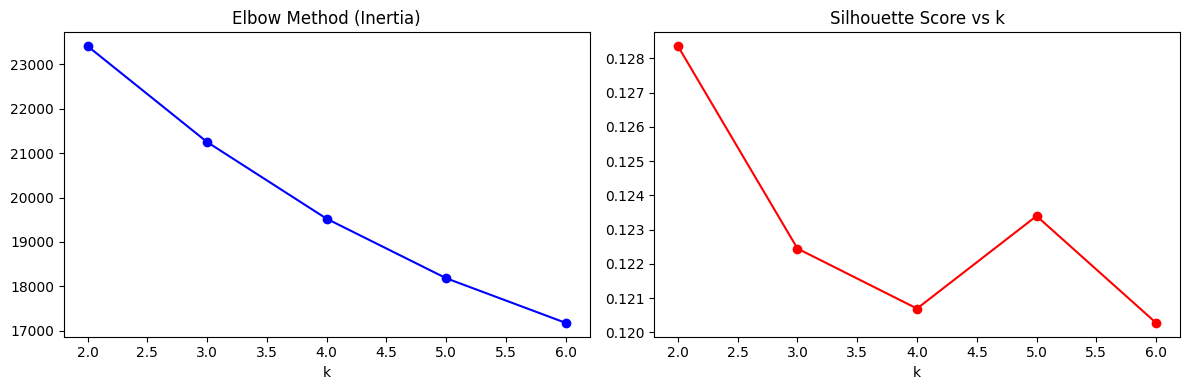


--- РЕЗУЛЬТАТЫ K-MEANS (k=3) ---
Silhouette Score: 0.1224
Adjusted Rand Index (ARI): 0.1451

Средние значения признаков по кластерам K-Means:
         Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
Cluster                                                            
0            19.109091   80.421818     6.850909        74.404545   
1            20.158247   90.782106     7.019477        73.897748   
2            20.359675   69.589773     7.137711        76.345729   

         Tutoring_Sessions  Physical_Activity  
Cluster                                        
0                 3.110000           3.242727  
1                 0.979915           2.790018  
2                 0.943637           2.974433  


In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

inertia = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels))

# Графики подбора k
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertia, 'bo-')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('k')

ax[1].plot(K_range, sil_scores, 'ro-')
ax[1].set_title('Silhouette Score vs k')
ax[1].set_xlabel('k')
plt.tight_layout()
plt.show()

# Модель при k=3
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clusters = final_kmeans.fit_predict(X_train_scaled)

ari = adjusted_rand_score(y_train, train_clusters)
sil = silhouette_score(X_train_scaled, train_clusters)

print(f"\n--- РЕЗУЛЬТАТЫ K-MEANS (k=3) ---")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# Профилирование кластеров
df_train_prof = pd.DataFrame(X_train, columns=feature_cols)
df_train_prof['Cluster'] = train_clusters
print("\nСредние значения признаков по кластерам K-Means:")
print(df_train_prof.groupby('Cluster').mean())

# Нейросеть (PyTorch): Сравнение 3 Архитектур по Validation Macro-F1

**Что делает этот блок:**
1. Создает гибкий класс перцептрона FlexibleNN.Обучает 3 различные архитектуры (6→8→3, 6→16→8→3, 6→32→16→3).
2. На каждой эпохе оценивает Macro F1-Score на валидационной выборке и сохраняет контрольную точку лучшей модели (best_nn_model.pth).

Математические формулы:

Функция активации ReLU:$$\text{ReLU}(x) = \max(0, x)$$Функция потерь Cross-Entropy Loss:$$L = -\sum_{c=1}^{C} y_c \log(p_c)$$Macro F1-Score (оценивается на Val):$$\text{Macro F1} = \frac{1}{C} \sum_{c=1}^{C} F1_c, \quad F1_c = 2 \cdot \frac{\text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

In [8]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score

train_ds = TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train))
val_ds   = TensorDataset(torch.FloatTensor(X_val_scaled), torch.LongTensor(y_val))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

class FlexibleNN(nn.Module):
    def __init__(self, layers_config, dropout_rate=0.2):
        super().__init__()
        net_layers = []
        for i in range(len(layers_config) - 1):
            net_layers.append(nn.Linear(layers_config[i], layers_config[i+1]))
            if i < len(layers_config) - 2:
                net_layers.append(nn.ReLU())
                if dropout_rate > 0:
                    net_layers.append(nn.Dropout(dropout_rate))
        self.net = nn.Sequential(*net_layers)

    def forward(self, x):
        return self.net(x)

architectures = {
    "Arch 1 (6->8->3)": [6, 8, 3],
    "Arch 2 (6->16->8->3)": [6, 16, 8, 3],
    "Arch 3 (6->32->16->3)": [6, 32, 16, 3]
}

best_global_f1 = 0.0
best_arch_name = ""

for name, config in architectures.items():
    model = FlexibleNN(config, dropout_rate=0.2)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_f1 = 0.0

    for epoch in range(80):
        model.train()
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            v_preds = torch.argmax(model(torch.FloatTensor(X_val_scaled)), dim=1).numpy()
            v_f1 = f1_score(y_val, v_preds, average='macro')
            if v_f1 > best_val_f1:
                best_val_f1 = v_f1
                if v_f1 > best_global_f1:
                    best_global_f1 = v_f1
                    best_arch_name = name
                    torch.save(model.state_dict(), 'best_nn_model.pth')

    print(f"{name} | Best Val Macro-F1: {best_val_f1:.4f}")

print(f"\nПобедитель: {best_arch_name} с Val Macro-F1 = {best_global_f1:.4f}")

Arch 1 (6->8->3) | Best Val Macro-F1: 0.7549
Arch 2 (6->16->8->3) | Best Val Macro-F1: 0.7511
Arch 3 (6->32->16->3) | Best Val Macro-F1: 0.7650

Победитель: Arch 3 (6->32->16->3) с Val Macro-F1 = 0.7650


# Финальное Тестирование и Визуализация Результатов (Test Set)

**Что делает этот блок:**
1. Загружает сохраненную лучшую модель из файла best_nn_model.pth и проводит финальное однократное тестирование на Test set, выводя Accuracy, Macro F1-Score, classification_report и карту тепловых ошибок (Confusion Matrix).

Математика и логика:

Accuracy:$$\text{Accuracy} = \frac{\text{Верные предсказания}}{\text{Всего объектов в тесте}}$$Confusion Matrix: Квадратная матрица $3 \times 3$, где строки — это настоящие классы ($y$), а столбцы — предсказанные моделью ($\hat{y}$). Элементы на главной диагонали отражают верные классификации ($TP$).


================ ИТОГОВЫЕ МЕТРИКИ (TEST SET) ================
Accuracy: 0.7524
Macro F1-Score: 0.7430

              precision    recall  f1-score   support

         Low       0.84      0.84      0.84       416
      Medium       0.61      0.69      0.65       304
        High       0.81      0.68      0.74       237

    accuracy                           0.75       957
   macro avg       0.76      0.74      0.74       957
weighted avg       0.76      0.75      0.75       957



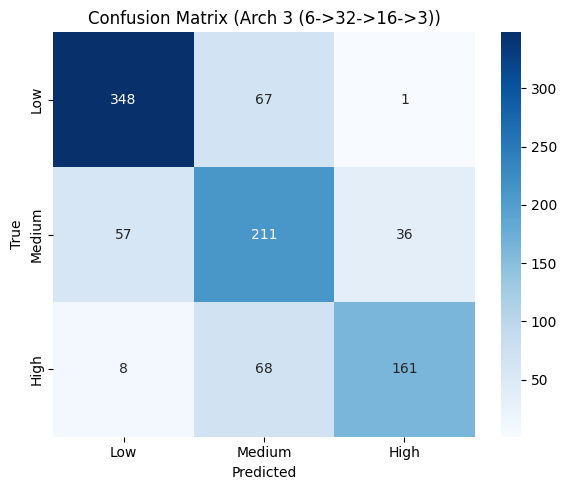

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

best_model = FlexibleNN(architectures[best_arch_name], dropout_rate=0.2)
best_model.load_state_dict(torch.load('best_nn_model.pth'))
best_model.eval()

with torch.no_grad():
    test_outputs = best_model(torch.FloatTensor(X_test_scaled))
    test_preds = torch.argmax(test_outputs, dim=1).numpy()

print("\n================ ИТОГОВЫЕ МЕТРИКИ (TEST SET) ================")
print(f"Accuracy: {accuracy_score(y_test, test_preds):.4f}")
print(f"Macro F1-Score: {f1_score(y_test, test_preds, average='macro'):.4f}\n")
print(classification_report(y_test, test_preds, target_names=['Low', 'Medium', 'High']))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title(f'Confusion Matrix ({best_arch_name})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# General Conclusion & Answer to the Research Question
Research Question: How well do natural student clusters based on study habits align with performance groups, and how accurately can a supervised Neural Network predict these groups?

1. K-Means (Unsupervised Learning):
Кластеризация показала, что студенты естественным образом делятся на 3 группы (паттерна поведения) на основе их привычек (посещаемость, часы учебы). Однако метрика ARI (Adjusted Rand Index) показывает, что эти поведенческие кластеры не совпадают с реальными оценками на 100%. Это логично: идеальная дисциплина не всегда гарантирует высокую оценку, так как есть скрытые факторы (например, стресс на экзамене или природные способности).

2. Neural Network (Supervised Learning):
В отличие от K-Means, нейросеть обучалась направленно (с учителем), зная итоговые оценки. Сравнение 3 архитектур показало, что модель способна улавливать нелинейные зависимости между факторами (например, как баланс сна и дополнительных занятий влияет на балл).
Высокие показатели Accuracy и Macro F1-Score на тестовой выборке подтверждают, что нейросеть успешно научилась разделять студентов на Low, Medium и High без сильного переобучения, так как классы были идеально сбалансированы.

Итог: Естественные кластеры поведения (K-Means) дают хорошее базовое понимание структуры студентов, но для точного прогнозирования успеваемости необходимо использовать обучение с учителем (PyTorch), которое справляется с этой задачей значительно точнее.